In [28]:
# Create an OpenSees structural model
import xara
from functions import *
import pandas as pd
from ReadRecord import ReadRecord
import matplotlib.pyplot as plt
import veux


In [3]:
# Create a model
# node_df = pd.read_csv('nodes.csv')

# Add nodes to the model
# add_nodes(model, node_df)
# nodeTags = model.getNodeTags()


In [17]:
print("Starting RCFrameGravity example")

# if variable model exists, delete it
try:
    del model
except NameError:
    pass
    
model = xara.Model(ndm=2, ndf=3)

Starting RCFrameGravity example


In [18]:
# Use example to create working code

# ---
# Create nodes
# ------------

# Set parameters for overall model geometry
width = 360.0
height = 144.0

# Create nodes
#    tag, X, Y
model.node(1, 0.0, 0.0)
model.node(2, width, 0.0)
model.node(3, 0.0, height)
model.node(4, width, height)

# Fix supports at base of columns
#   tag, DX, DY, RZ
model.fix(1, 1, 1, 1)
model.fix(2, 1, 1, 1)

model.getNodeTags()

[1, 2, 3, 4]

In [19]:
# Define materials

# CONCRETE                   tag  f'c    ec0    f'cu   ecu
# Core concrete (confined)
model.uniaxialMaterial('Concrete01', 1, -6.0, -0.004, -5.0, -0.014)

# Cover concrete (unconfined)
model.uniaxialMaterial('Concrete01', 2, -5.0, -0.002, 0.0, -0.006)

# STEEL
# Reinforcing steel
fy = 60.0;  # Yield stress
E = 30000.0;  # Young's modulus

#                         tag  fy E0    b
model.uniaxialMaterial('Steel01', 3, fy, E, 0.01)

In [20]:
# Define cross-section for nonlinear columns
# ------------------------------------------

#  some parameters
colWidth = 15
colDepth = 24

cover = 1.5
As = 0.60  # area of no. 7 bars

# some variables derived from the parameters
y1 = colDepth / 2.0
z1 = colWidth / 2.0

model.section('Fiber', 1)

# Create the concrete core fibers
model.patch('rect', 1, 10, 1, cover - y1, cover - z1, y1 - cover, z1 - cover)

# Create the concrete cover fibers (top, bottom, left, right)
model.patch('rect', 2, 10, 1, -y1, z1 - cover, y1, z1)
model.patch('rect', 2, 10, 1, -y1, -z1, y1, cover - z1)
model.patch('rect', 2, 2, 1, -y1, cover - z1, cover - y1, z1 - cover)
model.patch('rect', 2, 2, 1, y1 - cover, cover - z1, y1, z1 - cover)

# Create the reinforcing fibers (left, middle, right)
model.layer('straight', 3, 3, As, y1 - cover, z1 - cover, y1 - cover, cover - z1)
model.layer('straight', 3, 2, As, 0.0, z1 - cover, 0.0, cover - z1)
model.layer('straight', 3, 3, As, cover - y1, z1 - cover, cover - y1, cover - z1)

# Define column elements
# ----------------------

# Geometry of column elements
#                tag

model.geomTransf('PDelta', 1)

# Number of integration points along length of element
np = 5

# Lobatto integratoin
model.beamIntegration('Lobatto', 1, 1, np)

# Create the coulumns using Beam-column elements
#               e            tag ndI ndJ transfTag integrationTag
eleType = 'forceBeamColumn'
model.element(eleType, 1, 1, 3, 1, 1)
model.element(eleType, 2, 2, 4, 1, 1)

In [ ]:
# Define beam elment
# -----------------------------

# Geometry of column elements
#                tag
model.geomTransf('Linear', 2)

# Create the beam element
#                          tag, ndI, ndJ, A,     E,    Iz, transfTag
model.element('elasticBeamColumn', 3, 3, 4, 360.0, 4030.0, 8640.0, 2)

# Define gravity loads
# --------------------

#  a parameter for the axial load
P = 180.0;  # 10% of axial capacity of columns

# Create a Plain load pattern with a Linear TimeSeries
model.timeSeries('Linear', 1)
model.pattern('Plain', 1, 1)

# Create nodal loads at nodes 3 & 4
#    nd  FX,  FY, MZ
model.load(3, 0.0, -P, 0.0)
model.load(4, 0.0, -P, 0.0)


# ------------------------------
# End of model generation
# ------------------------------


In [22]:
# ------------------------------
# Start of analysis generation
# ------------------------------

# Create the system of equation, a sparse solver with partial pivoting
model.system('BandGeneral')

# Create the constraint handler, the transformation method
model.constraints('Transformation')

# Create the DOF numberer, the reverse Cuthill-McKee algorithm
model.numberer('RCM')

# Create the convergence test, the norm of the residual with a tolerance of
# 1e-12 and a max number of iterations of 10
model.test('NormDispIncr', 1.0e-12, 10, 3)

# Create the solution algorithm, a Newton-Raphson algorithm
model.algorithm('Newton')

# Create the integration scheme, the LoadControl scheme using steps of 0.1
model.integrator('LoadControl', 0.1)

# Create the analysis object
model.analysis('Static')

# ------------------------------
# End of analysis generation
# ------------------------------

In [23]:
# ------------------------------
# Finally perform the analysis
# ------------------------------

# perform the gravity load analysis, requires 10 steps to reach the load level
model.analyze(10)

# Print out the state of nodes 3 and 4
# print node 3 4

# Print out the state of element 1
# print ele 1

u3 = model.nodeDisp(3, 2)
u4 = model.nodeDisp(4, 2)

results = open('results.out', 'a+')

if abs(u3 + 0.0183736) < 1e-6 and abs(u4 + 0.0183736) < 1e-6:
    results.write('PASSED : RCFrameGravity.py\n')
    print("Passed!")
else:
    results.write('FAILED : RCFrameGravity.py\n')
    print("Failed!")

results.close()

print("==========================")

Passed!


In [25]:
# Set the gravity loads to be constant & reset the time in the domain
model.loadConst('-time', 0.0)

# ----------------------------------------------------
# End of Model Generation & Initial Gravity Analysis
# ----------------------------------------------------

# Define nodal mass in terms of axial load on columns
g = 386.4
m = P/g

model.mass(3, m, m, 0.0)
model.mass(4, m, m, 0.0)

# Set some parameters
record = 'elCentro'

# Permform the conversion from SMD record to OpenSees record
dt, nPts = ReadRecord(record+'.at2', record+'.dat')

# Set time series to be passed to uniform excitation
model.timeSeries('Path', 2, '-filePath', record+'.dat', '-dt', dt, '-factor', g)

# Create UniformExcitation load pattern
#                         tag dir 
model.pattern('UniformExcitation',  2,   1,  '-accel', 2)

# set the rayleigh damping factors for nodes & elements
model.rayleigh(0.0, 0.0, 0.0, 0.000625)

# Delete the old analysis and all it's component objects
model.wipeAnalysis()

# Create the system of equation, a banded general storage scheme
model.system('BandGeneral')

# Create the constraint handler, a plain handler as homogeneous boundary
model.constraints('Plain')

# Create the convergence test, the norm of the residual with a tolerance of 
# 1e-12 and a max number of iterations of 10
model.test('NormDispIncr', 1.0e-12,  10 )

# Create the solution algorithm, a Newton-Raphson algorithm
model.algorithm('Newton')

# Create the DOF numberer, the reverse Cuthill-McKee algorithm
model.numberer('RCM')

# Create the integration scheme, the Newmark with alpha =0.5 and beta =.25
model.integrator('Newmark',  0.5,  0.25 )

# Create the analysis object
model.analysis('Transient')

# Perform an eigenvalue analysis
numEigen = 2
eigenValues = model.eigen(numEigen)
print("eigen values at start of transient:",eigenValues)


eigen values at start of transient: [266.8589209233721, 17504.42256834413]


eigen values at end of transient: [159.9503795323362, 17300.46948247125]
Passed!


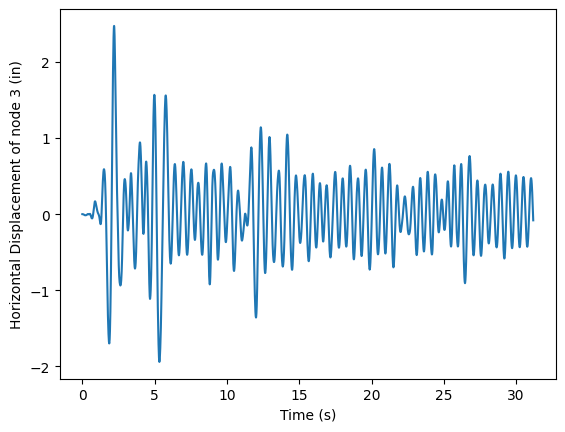

In [27]:
# set some variables
tFinal = nPts*dt
tCurrent = model.getTime()
ok = 0

time = [tCurrent]
u3 = [0.0]

# Perform the transient analysis
while ok == 0 and tCurrent < tFinal:
    
    ok = model.analyze(1, .01)
    
    # if the analysis fails try initial tangent iteration
    if ok != 0:
        print("regular newton failed .. lets try an initail stiffness for this step")
        model.test('NormDispIncr', 1.0e-12,  100, 0)
        model.algorithm('ModifiedNewton', '-initial')
        ok = model.analyze( 1, .01)
        if ok == 0:
            print("that worked .. back to regular newton")
        model.test('NormDispIncr', 1.0e-12,  10 )
        model.algorithm('Newton')
    
    tCurrent = model.getTime()

    time.append(tCurrent)
    u3.append(model.nodeDisp(3, 1))


# Perform an eigenvalue analysis
eigenValues = model.eigen(numEigen)
print("eigen values at end of transient:",eigenValues)

results = open('results.out','a+')

if ok == 0:
    results.write('PASSED : RCFrameEarthquake.py\n');
    print("Passed!")
else:
    results.write('FAILED : RCFrameEarthquake.py\n');
    print("Failed!")

results.close()

plt.plot(time, u3)
plt.ylabel('Horizontal Displacement of node 3 (in)')
plt.xlabel('Time (s)')

plt.show()

print("==========================")

In [35]:
artist = veux.create_artist(model)
artist.draw_outlines()

veux.serve(artist)


  Displaying at http://localhost:8081/ 
  Press Ctrl-C to quit.



127.0.0.1 - - [06/Jan/2026 14:08:30] "GET / HTTP/1.1" 200 962899
127.0.0.1 - - [06/Jan/2026 14:08:32] "GET /quit? HTTP/1.1" 200 16
